In [1]:
#Import required Libraries:
import pandas as pd
import os
from glob import glob
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Loading data set from the path:
base_data_dir = "E:/mit/project/dataset/"
df = pd.read_csv('E:/mit/project/dataset/HAM10000_metadata.csv')

In [3]:
# Validating dataset:
df.columns
df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [4]:
df.dtypes

lesion_id        object
image_id         object
dx               object
dx_type          object
age             float64
sex              object
localization     object
dtype: object

In [5]:
df.describe()

,age
count,9958.000000
mean,51.863828
std,16.968614
min,0.000000
25%,40.000000
50%,50.000000
75%,65.000000
max,85.000000


### Finding missing or null values from the data set:

In [6]:
df.isnull().sum()

lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dtype: int64

<p>
Feature "age" consists of 57 null values. Since, removing the 57 data can result loss of information. The optimal option is to replace the value.
</p>

In [7]:
## Filling teh missing or null value with mean value:
df['age'].fillna(int(df['age'].mean()),inplace=True)

C:\Users\nekir\AppData\Local\Temp\ipykernel_21272\2106507561.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(int(df['age'].mean()),inplace=True)


In [8]:
df.isnull().sum() #validating after replacing the null values with mean value:

lesion_id       0
image_id        0
dx              0
dx_type         0
age             0
sex             0
localization    0
dtype: int64

In [9]:
# Mapping the label data with codes:
lesion_type_dict = {
    'nv': 'Melanocytic nevi',
    'mel': 'Melanoma',
    'bkl': 'Benign keratosis-like lesions',
    'bcc': 'Basal cell carcinoma',
    'akiec': 'Actinic keratoses',
    'vasc': 'Vascular lesions',
    'df': 'Dermatofibroma'
}

df['cell_type'] = df['dx'].map(lesion_type_dict) # Mapping label data to code in column "cell type".

In [10]:
## Adding image file path from folders into single dataset:
imageid_path_dict = {os.path.splitext(os.path.basename(x))[0]: x
                     for x in glob(os.path.join(base_data_dir, '*', '*.jpg'))}

In [11]:
df['path'] = df['image_id'].map(imageid_path_dict.get)

In [12]:
df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,cell_type,path
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,Benign keratosis-like lesions,E:/mit/project/dataset\HAM10000_images_part_1\...
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,Benign keratosis-like lesions,E:/mit/project/dataset\HAM10000_images_part_1\...
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,Benign keratosis-like lesions,E:/mit/project/dataset\HAM10000_images_part_1\...
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,Benign keratosis-like lesions,E:/mit/project/dataset\HAM10000_images_part_1\...
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,Benign keratosis-like lesions,E:/mit/project/dataset\HAM10000_images_part_2\...


## Visualising the class distribution:

C:\Users\nekir\AppData\Local\Temp\ipykernel_21272\167944144.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')


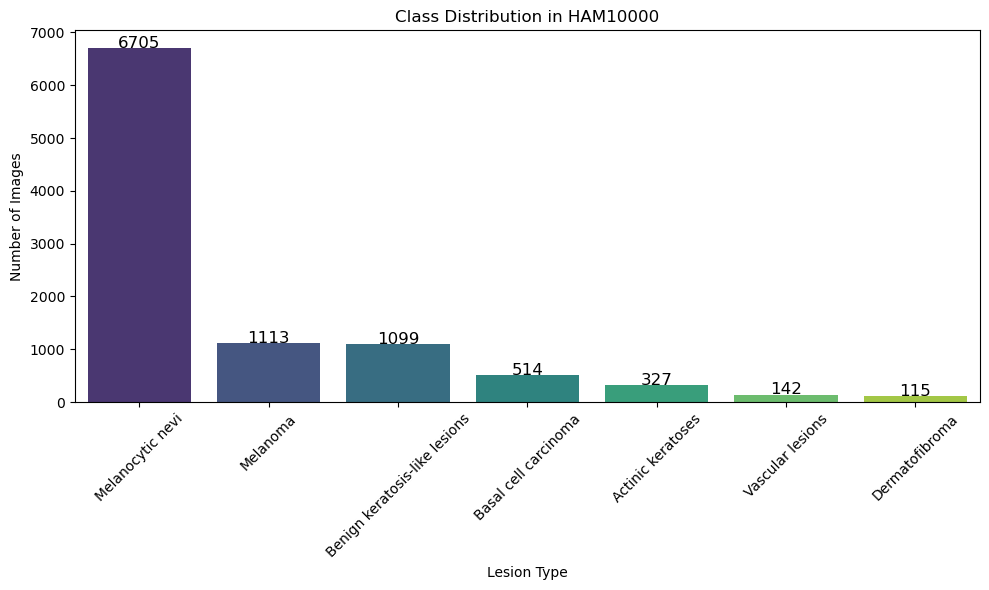

In [13]:
class_counts = df['cell_type'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')
plt.xticks(rotation=45)
plt.title('Class Distribution in HAM10000')
plt.xlabel('Lesion Type')
plt.ylabel('Number of Images')
plt.tight_layout()

# Adding total numbers at bar
for index, value in enumerate(class_counts.values):
    plt.text(index, value + 5, str(value), ha='center', fontsize=12)

plt.show()
plt.show()

# Resizing the image dataset with OpenCV:

In [14]:
# Import required libraries for image resizing:
import cv2
import numpy as np
from tqdm import tqdm

# Defining resize function:
def load_and_resize_cv2(path, size=(128, 128)):
    try:
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_resized = cv2.resize(img, size, interpolation=cv2.INTER_AREA)
        return img_resized
    except:
        return None

# df['image'] = df['path'].map(lambda x: load_and_resize_cv2(x))
# df.dropna(subset=['image'], inplace=True)

In [15]:
# Resizing the image:
df['image'] = df['path'].map(lambda x: load_and_resize_cv2(x))
df.dropna(subset=['image'], inplace=True)

# Split dataset into training and testing set:

In [16]:
from sklearn.model_selection import train_test_split

# Splitting the dataset into 75% training and 25% testing data set:
train_df, test_df = train_test_split(df, test_size=0.25, stratify=df['cell_type'], random_state=42)

# Augmenting dataset to handle class imbalance:

In [18]:
## importing required libraries for data augmentation (data image generator):
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array
from PIL import Image

In [ ]:
## Defining Augmentation function:
def augment_dataset(
    train_df, target_count=1500, save_dir="./augmented_images", img_size=(128, 128)
):
    datagen = ImageDataGenerator(
        rotation_range=30,
        width_shift_range=0.1,
        height_shift_range=0.1,
        shear_range=0.1,
        zoom_range=0.2,
        horizontal_flip=True,
        vertical_flip=True,
        fill_mode="nearest",
    )

    augmented = []
    class_counts = train_df["cell_type"].value_counts()

    for class_name, count in class_counts.items():
        if count >= target_count:
            continue
        subset = train_df[train_df["cell_type"] == class_name]
        generated = 0
        os.makedirs(f"{save_dir}/{class_name}", exist_ok=True)

        while generated < target_count - count:
            for _, row in subset.iterrows():
                if generated >= target_count - count:
                    break
                img = load_and_resize_cv2(row["path"], img_size)
                if img is None:
                    continue
                img_array = np.expand_dims(img, axis=0)
                aug_iter = datagen.flow(img_array, batch_size=1)
                aug_img = next(aug_iter)[0].astype(np.uint8)
                pil_img = Image.fromarray(aug_img)
                new_path = f"{save_dir}/{class_name}/{os.path.splitext(os.path.basename(row['path']))[0]}_aug{generated}.jpg"
                pil_img.save(new_path)
                augmented.append({"path": new_path, "cell_type": class_name})
                generated += 1

    aug_df = pd.DataFrame(augmented)
    return pd.concat([train_df, aug_df], ignore_index=True)

## Updated Augmentation Code:

In [20]:
# Example helper for loading and resizing (define as per your implementation)
def load_and_resize_cv2(path, img_size=(128, 128)):
    import cv2
    img = cv2.imread(path)
    if img is None:
        return None
    return cv2.resize(img, img_size)

def balance_and_augment_dataset(
    train_df, 
    target_count=2500, 
    save_dir="./augmented_images", 
    img_size=(128, 128)
):
    datagen = ImageDataGenerator(
        rotation_range=30,
        width_shift_range=0.1,
        height_shift_range=0.1,
        shear_range=0.1,
        zoom_range=0.2,
        horizontal_flip=True,
        vertical_flip=True,
        fill_mode="nearest",
    )

    balanced_data = []
    augmented = []
    class_counts = train_df["cell_type"].value_counts()

    for class_name, count in class_counts.items():
        subset = train_df[train_df["cell_type"] == class_name]

        if count > target_count:
            # Undersample majority class
            subset = subset.sample(target_count, random_state=42)
            balanced_data.append(subset)
        elif count < target_count:
            # Keep original and augment the rest
            balanced_data.append(subset)
            generated = 0
            os.makedirs(f"{save_dir}/{class_name}", exist_ok=True)

            while generated < (target_count - count):
                for _, row in subset.iterrows():
                    if generated >= (target_count - count):
                        break
                    img = load_and_resize_cv2(row["path"], img_size)
                    if img is None:
                        continue
                    img_array = np.expand_dims(img, axis=0)
                    aug_iter = datagen.flow(img_array, batch_size=1)
                    aug_img = next(aug_iter)[0].astype(np.uint8)
                    pil_img = Image.fromarray(aug_img)
                    new_path = f"{save_dir}/{class_name}/{os.path.splitext(os.path.basename(row['path']))[0]}_aug{generated}.jpg"
                    pil_img.save(new_path)
                    augmented.append({"path": new_path, "cell_type": class_name})
                    generated += 1
        else:
            # Keeping target value as it is:
            balanced_data.append(subset)

    # Combine real + augmented data
    real_df = pd.concat(balanced_data, ignore_index=True)
    aug_df = pd.DataFrame(augmented)
    final_df = pd.concat([real_df, aug_df], ignore_index=True)

    return final_df


### END OF DATA AUGMENTATION:

In [21]:
train_df = balance_and_augment_dataset(train_df)

In [22]:
# Loading the image and creating final data:
train_df['image'] = train_df['path'].map(lambda x: load_and_resize_cv2(x))
test_df['image'] = test_df['path'].map(lambda x: load_and_resize_cv2(x))


C:\Users\nekir\AppData\Local\Temp\ipykernel_21272\2835971727.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=aug_class_counts.index, y=aug_class_counts.values, palette='viridis')


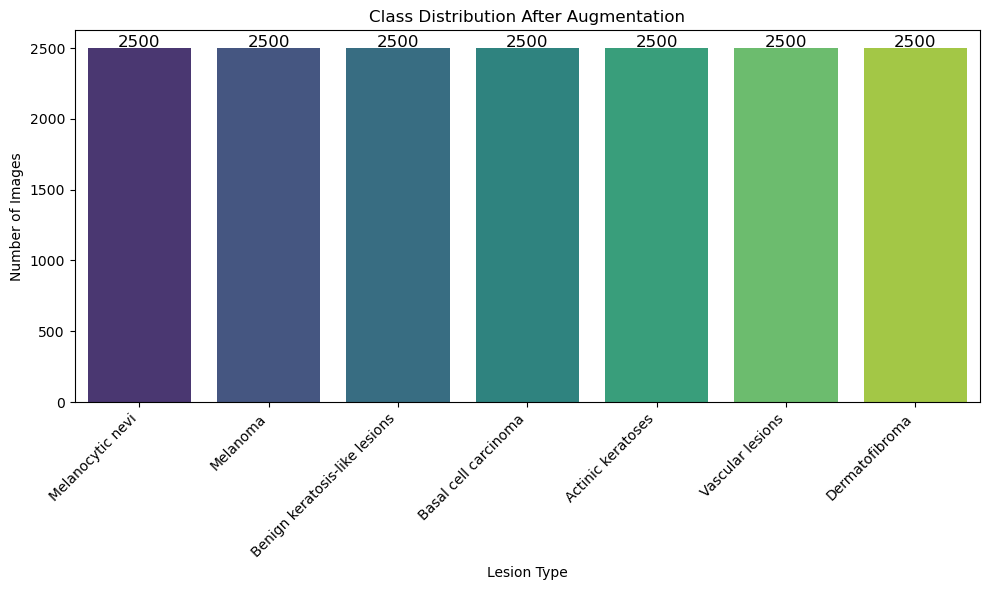

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count samples per class
aug_class_counts = train_df['cell_type'].value_counts()

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=aug_class_counts.index, y=aug_class_counts.values, palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.xlabel("Lesion Type")
plt.ylabel("Number of Images")
plt.title("Class Distribution After Augmentation")

# Annotate counts above bars
for index, value in enumerate(aug_class_counts.values):
    plt.text(index, value + 10, str(value), ha='center', fontsize=12)

plt.tight_layout()
plt.show()


In [24]:
train_df.isnull().sum()

lesion_id       12518
image_id        12518
dx              12518
dx_type         12518
age             12518
sex             12518
localization    12518
cell_type           0
path                0
image               0
dtype: int64

<p> 
    Since the image augmentation created new images, and ther are null values in columns such as sex, age and other columns. In order to handle the NA or null values, those section are filled with mean value to preserve the information.
</p>

In [26]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Fill missing age and encode sex/localization
train_df['age'].fillna(train_df['age'].mean(), inplace=True)
train_df['sex'].fillna('unknown', inplace=True)
train_df['localization'].fillna('unknown', inplace=True)

# One-hot encode categorical features
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
metadata_ohe = ohe.fit_transform(train_df[['sex', 'localization']])

# Normalize age
scaler = StandardScaler()
age_scaled = scaler.fit_transform(train_df[['age']])

# Combine into single metadata array
metadata_input = np.concatenate([age_scaled, metadata_ohe], axis=1)


C:\Users\nekir\AppData\Local\Temp\ipykernel_21272\1113030341.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['age'].fillna(train_df['age'].mean(), inplace=True)


# Normalising and Econding the Image data:

In [27]:
# importing required libraries:
from tensorflow.keras.utils import to_categorical

In [28]:
train_df['cell_type_idx'] = pd.Categorical(train_df['cell_type']).codes
test_df['cell_type_idx'] = pd.Categorical(test_df['cell_type']).codes


In [29]:
x_train = np.stack(train_df['image'].values)
x_test = np.stack(test_df['image'].values)


In [30]:
x_train = (x_train - np.mean(x_train)) / np.std(x_train) # NORMALISATION BACKUP CODE

In [ ]:
#Normalising the image data:
x_train = x_train.astype('float32')
x_train = (x_train - np.mean(x_train)) / np.std(x_train)


In [29]:
x_train = np.array([
    (img.astype('float32') - np.mean(img)) / np.std(img)
    for img in x_train
], dtype='float32')

KeyboardInterrupt: 

In [31]:
x_test = (x_test - np.mean(x_test)) / np.std(x_test)

In [32]:
# Using one hot encoding to convert the values:
y_train = to_categorical(train_df['cell_type_idx'], num_classes=7)
y_test = to_categorical(test_df['cell_type_idx'], num_classes=7)

In [33]:

## Dropping the NA values:
train_df.dropna(subset=['image'], inplace=True)

test_df.dropna(subset=['image'], inplace=True)

### CNN MODEL:

In [34]:
from tensorflow.keras.layers import Flatten,Dense,Dropout,BatchNormalization,Conv2D, MaxPool2D
from keras.optimizers import Adam
from keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [35]:
from keras.models import Sequential

In [35]:
# Set the CNN model 
# CNN architechture is In -> [[Conv2D->relu]*2 -> MaxPool2D -> Dropout]*3 -> Flatten -> Dense*2 -> Dropout -> Out

# Adding Batch Normalisation Layer: it helps stabilise the model and accelerate training.
# Added Early Stopping to avoid potential overfitting by stopping training.
input_shape = (128, 128, 3)
num_classes = 7

model = Sequential()
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', padding='Same', input_shape=input_shape))
model.add(BatchNormalization())
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', padding='Same'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(0.16))

model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', padding='Same'))
model.add(BatchNormalization())
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', padding='Same'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(0.20))

model.add(Conv2D(64, (3, 3), activation='relu', padding='Same'))
model.add(BatchNormalization())
model.add(Conv2D(64, (3, 3), activation='relu', padding='Same'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(num_classes, activation='softmax'))
model.summary()

e:\uni_mit\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,79

 Total params: 4,281,447 (16.33 MB)

 Trainable params: 4,280,935 (16.33 MB)

 Non-trainable params: 512 (2.00 KB)

In [36]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import ExponentialDecay

# # Define the learning rate schedule
# learning_rate_schedule = ExponentialDecay(
#     initial_learning_rate=0.0001,  # Initial learning rate
#     decay_steps=100000,            # Number of steps before applying decay
#     decay_rate=0.96,               # Decay rate for the learning rate
#     staircase=True                 # If True, learning rate decays at discrete intervals
# )

# Define the optimizer with the learning rate schedule
optimizer = Adam(learning_rate=0.001)

In [37]:
# Compile the model
model.compile(optimizer = optimizer , loss = "categorical_crossentropy", metrics=["accuracy"])

In [37]:
# Set a learning rate annealer
learning_rate_reduction = ReduceLROnPlateau(
    monitor='val_accuracy',
    patience=4,
    verbose=1,
    factor=0.5,
    min_lr=0.00001
)

In [38]:
x_train, x_validate, y_train, y_validate = train_test_split(x_train, y_train, test_size = 0.1, random_state = 999)
# Reshape image in 3 dimensions (height = 128, width = 128 , canal = 3)

x_train = x_train.reshape(x_train.shape[0], *(128, 128, 3))
x_test = x_test.reshape(x_test.shape[0], *(128, 128, 3))
x_validate = x_validate.reshape(x_validate.shape[0], *(128, 128, 3))
# With data augmentation to prevent overfitting 




In [39]:
datagen = ImageDataGenerator(
        featurewise_center=False,  # set input mean to 0 over the dataset
        samplewise_center=False,  # set each sample mean to 0
        featurewise_std_normalization=False,  # divide inputs by std of the dataset
        samplewise_std_normalization=False,  # divide each input by its std
        zca_whitening=False,  # apply ZCA whitening
        rotation_range=10,  # randomly rotate images in the range (degrees, 0 to 180)
        zoom_range = 0.1, # Randomly zoom image 
        width_shift_range=0.12,  # randomly shift images horizontally (fraction of total width)
        height_shift_range=0.12,  # randomly shift images vertically (fraction of total height)
        horizontal_flip=True,  # randomly flip images
        vertical_flip=True)  # randomly flip images

datagen.fit(x_train)

In [40]:
# STEP 1: Convert one-hot labels back to integers
y_train_labels = np.argmax(y_train, axis=1)

# STEP 2: Compute class weights
from sklearn.utils import class_weight
import numpy as np

weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels
)
class_weights = dict(enumerate(weights))

In [42]:
# Fit the model
epochs = 20
batch_size = 16
# history = model.fit_generator(datagen.flow(x_train,y_train, batch_size=batch_size),
#                               epochs = epochs, validation_data = (x_validate,y_validate),
#                               verbose = 1, steps_per_epoch=x_train.shape[0] // batch_size
#                               , callbacks=[learning_rate_reduction])

history = model.fit(
    datagen.flow(x_train, y_train, batch_size=batch_size),
    epochs=epochs,
    validation_data=(x_validate, y_validate),
    verbose=1,
    steps_per_epoch=x_train.shape[0] // batch_size,
    callbacks=[learning_rate_reduction],
    class_weight = class_weights
)

Epoch 1/20


e:\uni_mit\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


196/196 ━━━━━━━━━━━━━━━━━━━━ 51s 246ms/step - accuracy: 0.2707 - loss: 5.0923 - val_accuracy: 0.2600 - val_loss: 4.0998 - learning_rate: 0.0010
Epoch 2/20
  1/196 ━━━━━━━━━━━━━━━━━━━━ 45s 231ms/step - accuracy: 0.3750 - loss: 1.5503

e:\uni_mit\Lib\site-packages\keras\src\trainers\epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3750 - loss: 1.5503 - val_accuracy: 0.2657 - val_loss: 4.1508 - learning_rate: 0.0010
Epoch 3/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 48s 246ms/step - accuracy: 0.3671 - loss: 1.6825 - val_accuracy: 0.4257 - val_loss: 2.0694 - learning_rate: 0.0010
Epoch 4/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2500 - loss: 1.6975 - val_accuracy: 0.4286 - val_loss: 2.1616 - learning_rate: 0.0010
Epoch 5/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 48s 245ms/step - accuracy: 0.3643 - loss: 1.6339 - val_accuracy: 0.4314 - val_loss: 1.6192 - learning_rate: 0.0010
Epoch 6/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4375 - loss: 1.4051 - val_accuracy: 0.4314 - val_loss: 1.6714 - learning_rate: 0.0010
Epoch 7/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 49s 247ms/step - accuracy: 0.3852 - loss: 1.5834 - val_accuracy: 0.4343 - val_loss: 1.7455 - learning_rate: 0.0010
Epoch 8/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6875 - loss: 1.5478 - va

In [41]:
print(x_train.shape)

(3150, 128, 128, 3)


In [42]:

# Saving simple CNN Model:
model.save("simple_cnn.h5")

In [61]:
model.save("simple_cnn.keras")

In [43]:
# CNN fitted model plot:
from tensorflow.keras.utils import plot_model
plot_model(model, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


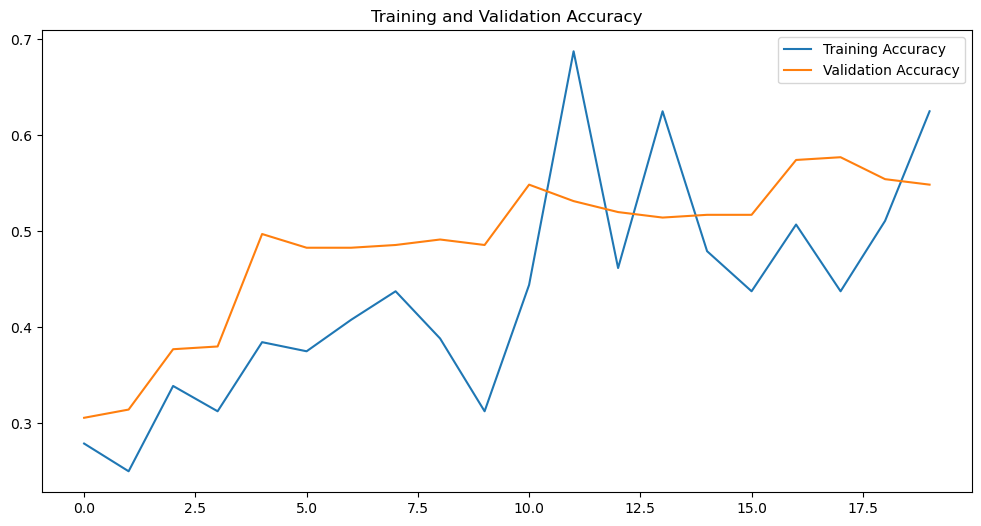

In [44]:
import matplotlib.pyplot as plt

# Training and validation accuracy plot:
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

In [45]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f'Test Accuracy of CNN model: {test_accuracy * 100:.2f}%')
print(f'Test Loss of CNN model: {test_loss * 100:.2f}%')

79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 70ms/step - accuracy: 0.5786 - loss: 1.0303
Test Accuracy of CNN model: 55.59%
Test Loss of CNN model: 105.78%


In [46]:
import numpy as np

# Predict on test data
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)  # assuming y_test is one-hot encoded


79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 73ms/step


In [47]:
# Calculating Precision, Recall and F1 Score:
from sklearn.metrics import classification_report

# Example class names for HAM10000 dataset (replace with your actual class names if different)
class_names = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']

print(classification_report(y_true, y_pred, target_names=class_names))


              precision    recall  f1-score   support

       akiec       0.00      0.00      0.00        82
         bcc       0.32      0.70      0.44       129
         bkl       0.30      0.54      0.39       275
          df       0.12      0.07      0.09        29
         mel       0.95      0.58      0.72      1676
          nv       0.25      0.55      0.34       278
        vasc       0.26      0.57      0.36        35

    accuracy                           0.56      2504
   macro avg       0.32      0.43      0.34      2504
weighted avg       0.72      0.56      0.59      2504



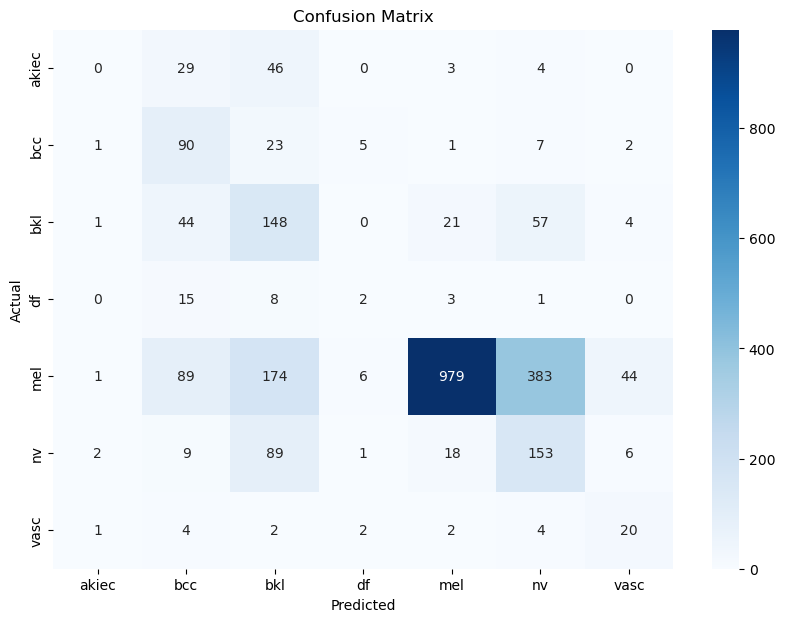

In [48]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [41]:
#Import required libraries for Xception Model:
import tensorflow as tf
from tensorflow.keras.layers import Input,Dense,Conv2D,Add
from tensorflow.keras.layers import SeparableConv2D,ReLU
from tensorflow.keras.layers import BatchNormalization,MaxPool2D
from tensorflow.keras.layers import GlobalAvgPool2D
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras import Model

from tensorflow.keras.applications import Xception

In [42]:
# Adding Conv-BatchNorm block:
def conv_bn(x, filters, kernel_size, strides=1):
    x = Conv2D(
        filters=filters,
        kernel_size=kernel_size,
        strides=strides,
        padding='same',
        use_bias=False
    )(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    return x

# SeparableConv-BatchNorm block


def sep_bn(x, filters, kernel_size, strides=1):
    x = SeparableConv2D(filters=filters,
                        kernel_size=kernel_size,
                        strides=strides,
                        padding='same',
                        use_bias=False)(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    return x

# Entry Flow
def entry_flow(x):
    x = conv_bn(x, filters=32, kernel_size=3, strides=2)
    x = conv_bn(x, filters=64, kernel_size=3, strides=1)

    tensor = x

    x = sep_bn(tensor, filters=128, kernel_size=3)
    x = sep_bn(x, filters=128, kernel_size=3)
    x = MaxPool2D(pool_size=3, strides=2, padding='same')(x)

    tensor = conv_bn(tensor, filters=128, kernel_size=1, strides=2)
    x = Add()([tensor, x])

    x = sep_bn(x, filters=256, kernel_size=3)
    x = sep_bn(x, filters=256, kernel_size=3)
    x = MaxPool2D(pool_size=3, strides=2, padding='same')(x)

    tensor = conv_bn(tensor, filters=256, kernel_size=1, strides=2)
    x = Add()([tensor, x])

    x = sep_bn(x, filters=728, kernel_size=3)
    x = sep_bn(x, filters=728, kernel_size=3)
    x = MaxPool2D(pool_size=3, strides=2, padding='same')(x)

    tensor = conv_bn(tensor, filters=728, kernel_size=1, strides=2)
    x = Add()([tensor, x])

    return x

# Middle Flow


def middle_flow(tensor):
    for _ in range(8):
        x = sep_bn(tensor, filters=728, kernel_size=3)
        x = sep_bn(x, filters=728, kernel_size=3)
        x = sep_bn(x, filters=728, kernel_size=3)
        tensor = Add()([tensor, x])

    return tensor

# Exit Flow


def exit_flow(tensor):
    x = sep_bn(tensor, filters=728, kernel_size=3)
    x = sep_bn(x, filters=1024, kernel_size=3)
    x = MaxPool2D(pool_size=3, strides=2, padding='same')(x)

    tensor = conv_bn(tensor, filters=1024, kernel_size=1, strides=2)
    x = Add()([tensor, x])

    x = sep_bn(x, filters=1536, kernel_size=3)
    x = sep_bn(x, filters=2048, kernel_size=3)
    x = GlobalAveragePooling2D()(x)

    x = Dense(units=256, activation='relu')(x)
    x = Dropout(0.5)(x)
    output = Dense(units=7, activation='softmax')(
        x)  # Adjusted for your 7 classes

    return output

In [43]:
# Loading Pre-trained Xception Model:
base_model = Xception(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
base_model.trainable = True  # Allow fine-tuning

In [44]:
# Model Definition
input = base_model.input
x = entry_flow(input)
x = middle_flow(x)
output = exit_flow(x)

xception_model = Model(inputs=input, outputs=output)
xception_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │     18,432 │ re_lu[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d    │ (None, 64, 64,    │      8,768 │ re_lu_1[0][0]     │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ separable_conv2d… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_1  │ (None, 64, 64,    │     17,536 │ re_lu_2[0][0]     │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │      8,192 │ re_lu_1[0][0]     │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ separable_conv2d… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ conv2d_6[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_4 (ReLU)      │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 32, 32,    │          0 │ re_lu_3[0][0]   

 Total params: 21,387,823 (81.59 MB)

 Trainable params: 21,333,295 (81.38 MB)

 Non-trainable params: 54,528 (213.00 KB)

In [45]:

# Compile the model
xception_model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

## Training Xception Model:

In [46]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Callbacks
checkpoint = ModelCheckpoint(
    'improved_xception_model.keras', monitor='val_loss', save_best_only=True, verbose=1)
early_stopping = EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
learning_rate_reduction = ReduceLROnPlateau(
    monitor='val_accuracy', patience=3, verbose=1, factor=0.5, min_lr=0.00001)

# Training the model
BATCH_SIZE = 32
EPOCHS = 20

xception_history = xception_model.fit(
    datagen.flow(x_train, y_train, batch_size=BATCH_SIZE),
    validation_data=(x_validate, y_validate),
    steps_per_epoch=len(x_train) // BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=[checkpoint, early_stopping, learning_rate_reduction]
)

e:\uni_mit\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
492/492 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4114 - loss: 1.5224
Epoch 1: val_loss improved from inf to 1.40857, saving model to improved_xception_model.keras
492/492 ━━━━━━━━━━━━━━━━━━━━ 856s 2s/step - accuracy: 0.4114 - loss: 1.5221 - val_accuracy: 0.4269 - val_loss: 1.4086 - learning_rate: 0.0010
Epoch 2/20
  1/492 ━━━━━━━━━━━━━━━━━━━━ 13:54 2s/step - accuracy: 0.3438 - loss: 1.3286

e:\uni_mit\Lib\site-packages\keras\src\trainers\epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_loss improved from 1.40857 to 1.40763, saving model to improved_xception_model.keras
492/492 ━━━━━━━━━━━━━━━━━━━━ 20s 38ms/step - accuracy: 0.3438 - loss: 1.3286 - val_accuracy: 0.4217 - val_loss: 1.4076 - learning_rate: 0.0010
Epoch 3/20
492/492 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5018 - loss: 1.2614
Epoch 3: val_loss did not improve from 1.40763
492/492 ━━━━━━━━━━━━━━━━━━━━ 821s 2s/step - accuracy: 0.5018 - loss: 1.2614 - val_accuracy: 0.4331 - val_loss: 1.6264 - learning_rate: 0.0010
Epoch 4/20
  1/492 ━━━━━━━━━━━━━━━━━━━━ 13:27 2s/step - accuracy: 0.5312 - loss: 1.0400
Epoch 4: val_loss did not improve from 1.40763
492/492 ━━━━━━━━━━━━━━━━━━━━ 17s 31ms/step - accuracy: 0.5312 - loss: 1.0400 - val_accuracy: 0.4377 - val_loss: 1.5851 - learning_rate: 0.0010
Epoch 5/20
492/492 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5544 - loss: 1.1562
Epoch 5: val_loss improved from 1.40763 to 1.07576, saving model to improved_xception_model.keras
492/492 ━━━━━━━━━━━━━━━

In [47]:

# Saving simple CNN Model:
xception_model.save("xception_model_updated_500.h5")

In [48]:
# Verify Test Accuracy and Loss
test_loss, test_accuracy = xception_model.evaluate(x_test, y_test)
print(f'Test Accuracy of Xception Model : {test_accuracy * 100:.2f}%')
print(f'Test Loss of Xception Model : {test_loss * 100:.2f}%')

79/79 ━━━━━━━━━━━━━━━━━━━━ 23s 291ms/step - accuracy: 0.7484 - loss: 0.7136
Test Accuracy of Xception Model : 74.60%
Test Loss of Xception Model : 73.66%


In [43]:
## Testing CNN model:

#Importing libraries:
import tensorflow as tf

In [49]:
import numpy as np

# Predict on test data
y_pred_probs_xception_model = xception_model.predict(x_test)
y_pred_xception_model = np.argmax(y_pred_probs_xception_model, axis=1)
y_true_xception_model = np.argmax(y_test, axis=1)  # assuming y_test is one-hot encoded


79/79 ━━━━━━━━━━━━━━━━━━━━ 24s 298ms/step


In [50]:
# Calculating Precision, Recall and F1 Score:
from sklearn.metrics import classification_report

# Example class names for HAM10000 dataset (replace with your actual class names if different)
class_names = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']

print(classification_report(y_true_xception_model, y_pred_xception_model, target_names=class_names))


              precision    recall  f1-score   support

       akiec       0.55      0.55      0.55        82
         bcc       0.49      0.73      0.59       129
         bkl       0.47      0.44      0.45       275
          df       0.86      0.41      0.56        29
         mel       0.88      0.86      0.87      1676
          nv       0.45      0.50      0.48       278
        vasc       0.81      0.60      0.69        35

    accuracy                           0.75      2504
   macro avg       0.64      0.58      0.60      2504
weighted avg       0.76      0.75      0.75      2504



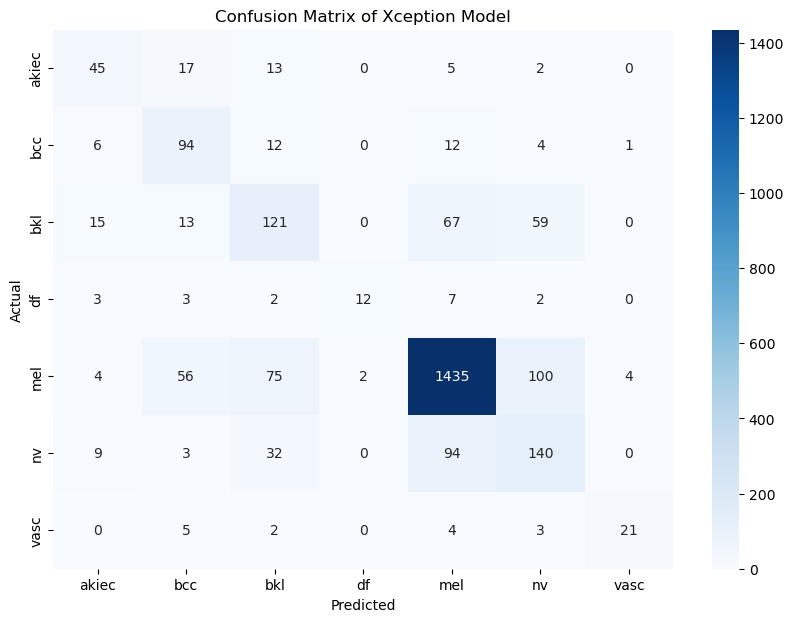

In [51]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Compute confusion matrix
cm = confusion_matrix(y_true_xception_model, y_pred_xception_model)

# Plot
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix of Xception Model')
plt.show()

In [48]:
xception_model.save("xception_model_updated.h5")

In [62]:
xception_model.save("xception_model_updated.keras")

In [52]:
from tensorflow.keras.models import load_model

model = load_model("xception_model_updated_500.h5")


In [53]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.xception import preprocess_input
import numpy as np

class_names = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']

def predict_image(model, image_path, input_size=(128, 128)):
    img = load_img(image_path, target_size=input_size)
    img_array = img_to_array(img)
    img_array = preprocess_input(img_array)  # Use Xception's preprocessing
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)[0]
    predicted_index = np.argmax(prediction)
    predicted_label = class_names[predicted_index]
    confidence_scores = {class_names[i]: float(f"{prob:.4f}") for i, prob in enumerate(prediction)}

    return predicted_label, confidence_scores

In [54]:
image_path = "Ballarat-Skin-Cancer-Centre-naevus-2.jpg"  # or your full path

predicted_label, confidence = predict_image(model, image_path)

print(f"\n Predicted Class: {predicted_label}")
print(" Confidence Scores:")
for cls, prob in confidence.items():
    print(f"{cls}: {prob}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 650ms/step

🔍 Predicted Class: bcc
📊 Confidence Scores:
akiec: 0.0156
bcc: 0.9008
bkl: 0.0682
df: 0.0013
mel: 0.0072
nv: 0.0049
vasc: 0.002


In [55]:
image_path = "ISIC_0024307.jpg"  # or your full path

predicted_label, confidence = predict_image(model, image_path)

print(f"\n Predicted Class: {predicted_label}")
print(" Confidence Scores:")
for cls, prob in confidence.items():
    print(f"{cls}: {prob}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step

🔍 Predicted Class: bcc
📊 Confidence Scores:
akiec: 0.0151
bcc: 0.8499
bkl: 0.1159
df: 0.0019
mel: 0.0109
nv: 0.0052
vasc: 0.0012


In [53]:
## Importing required libraries:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [54]:
# === MODEL CONFIG ===
input_shape = (128, 128, 3)
num_classes = 7


In [55]:
# === BASE MODEL ===
base_model_efficientNet = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=input_shape
)
base_model_efficientNet.trainable = True  # Fine-tune entire model

In [56]:
# === CUSTOM HEAD ===
efficientnet_inputs = base_model_efficientNet.input
x = GlobalAveragePooling2D()(base_model_efficientNet.output)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(num_classes, activation='softmax')(x)


In [57]:
# === COMPILE ===
efn_model_compile = Model(inputs=efficientnet_inputs, outputs=outputs)
optimizer = Adam(learning_rate=0.0001)
efn_model_compile.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [58]:
# === CALLBACKS ===
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
lr_reduce = ReduceLROnPlateau(monitor='val_accuracy', patience=3, factor=0.5, min_lr=1e-6, verbose=1)

#### Training the EfficientNetB0 model:

In [63]:
efn_history = efn_model_compile.fit(
    datagen.flow(x_train, y_train, batch_size=32),
    epochs=25,
    validation_data=(x_validate, y_validate),
    steps_per_epoch=len(x_train) // 32,
    callbacks=[early_stop, lr_reduce]
)

e:\uni_mit\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
393/393 ━━━━━━━━━━━━━━━━━━━━ 278s 642ms/step - accuracy: 0.4068 - loss: 1.5266 - val_accuracy: 0.2314 - val_loss: 1.8969 - learning_rate: 1.0000e-04
Epoch 2/25
  1/393 ━━━━━━━━━━━━━━━━━━━━ 3:59 610ms/step - accuracy: 0.6250 - loss: 0.9738

e:\uni_mit\Lib\site-packages\keras\src\trainers\epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


393/393 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.6250 - loss: 0.9738 - val_accuracy: 0.2357 - val_loss: 1.8951 - learning_rate: 1.0000e-04
Epoch 3/25
393/393 ━━━━━━━━━━━━━━━━━━━━ 246s 625ms/step - accuracy: 0.6952 - loss: 0.8187 - val_accuracy: 0.4564 - val_loss: 1.3754 - learning_rate: 1.0000e-04
Epoch 4/25
393/393 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8750 - loss: 0.5440 - val_accuracy: 0.4764 - val_loss: 1.3570 - learning_rate: 1.0000e-04
Epoch 5/25
393/393 ━━━━━━━━━━━━━━━━━━━━ 247s 629ms/step - accuracy: 0.7614 - loss: 0.6439 - val_accuracy: 0.7600 - val_loss: 0.6221 - learning_rate: 1.0000e-04
Epoch 6/25
393/393 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.7500 - loss: 0.7191 - val_accuracy: 0.7536 - val_loss: 0.6354 - learning_rate: 1.0000e-04
Epoch 7/25
393/393 ━━━━━━━━━━━━━━━━━━━━ 247s 628ms/step - accuracy: 0.8035 - loss: 0.5315 - val_accuracy: 0.8143 - val_loss: 0.4889 - learning_rate: 1.0000e-04
Epoch 8/25
393/393 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accur

In [64]:
test_loss, test_accuracy = efn_model_compile.evaluate(x_test, y_test)
print(f'Test Accuracy of EfficientNetB0: {test_accuracy * 100:.2f}%')
print(f'Test Loss of EfficientNetB0: {test_loss * 100:.2f}%')

79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 103ms/step - accuracy: 0.8362 - loss: 0.4726
Test Accuracy of EfficientNetB0: 82.11%
Test Loss of EfficientNetB0: 51.33%


In [65]:
efn_model_compile.save("efn_model.keras")

In [66]:
efn_model_compile.save("efn_model.h5")

In [87]:
from tensorflow.keras.models import load_model

model = load_model("efn_model.h5")

In [76]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.xception import preprocess_input
import numpy as np

class_names = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']

def predict_image(model, image_path, input_size=(128, 128)):
    img = load_img(image_path, target_size=input_size)
    img_array = img_to_array(img)
    img_array = preprocess_input(img_array)  # Use Xception's preprocessing
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)[0]
    predicted_index = np.argmax(prediction)
    predicted_label = class_names[predicted_index]
    confidence_scores = {class_names[i]: float(f"{prob:.4f}") for i, prob in enumerate(prediction)}

    return predicted_label, confidence_scores

In [77]:
image_path = "Ballarat-Skin-Cancer-Centre-naevus-2.jpg"  # or your full path

predicted_label, confidence = predict_image(model, image_path)

print(f"\n Predicted Class: {predicted_label}")
print(" Confidence Scores:")
for cls, prob in confidence.items():
    print(f"{cls}: {prob}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step

🔍 Predicted Class: bkl
📊 Confidence Scores:
akiec: 0.0029
bcc: 0.001
bkl: 0.7472
df: 0.0057
mel: 0.2358
nv: 0.003
vasc: 0.0042


In [89]:
image_path = "ISIC_0024307.jpg"  # or your full path

predicted_label, confidence = predict_image(model, image_path)

print(f"\n Predicted Class: {predicted_label}")
print(" Confidence Scores:")
for cls, prob in confidence.items():
    print(f"{cls}: {prob}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step

🔍 Predicted Class: mel
📊 Confidence Scores:
akiec: 0.0011
bcc: 0.0026
bkl: 0.3474
df: 0.1037
mel: 0.5363
nv: 0.0022
vasc: 0.0067
